In [1]:
import pandas as pd

In [2]:
from nsepy import get_history as gh
import datetime as dt

In [3]:
import yfinance as yf
import pandas as pd
import datetime as dt

start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2021-07-01  954.592529  966.058798  953.250218  963.715501    12534407
2021-07-02  968.743347  970.495163  952.317401  954.160205    14086620
2021-07-05  978.366882  979.891169  969.858139  972.110448    11702287
2021-07-06  966.809570  977.775346  964.716550  975.978096    10070124
2021-07-07  960.098145  968.151889  954.615287  968.151889    10454892


In [4]:
stk_data=stk_data[["Open","High","Low","Close"]]
#stk_data.to_csv("Tatacoffee13_21.csv")

In [5]:
column="Close"

In [6]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (144, 1)


In [7]:
training_size = round(len(data1 ) * 0.95)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

137
X_train length: (137, 1)
X_test length: (7, 1)
y_train length: (137, 1)
y_test length: (7, 1)


In [8]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

trends = ['n','t','c','ct']

for td in trends:

    model = ARIMA(X_train, order=(0,0,2), trend=td)   # MA model
    model_fit = model.fit()

    # prediction
    y_pred = model_fit.predict(len(X_train), len(data1)-1)

    mse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("Trend={}".format(td))
    print("RMSE:", mse)
    print("****")

Trend=n
RMSE: 0.5121150961248985
****
Trend=t
RMSE: 0.32611472500306515
****
Trend=c
RMSE: 0.1025593741753714
****
Trend=ct
RMSE: 0.24726764029727868
****


In [10]:
print(y_test)

[[0.69844222]
 [0.69815528]
 [0.6347712 ]
 [0.63534546]
 [0.49185235]
 [0.48517685]
 [0.43471393]]


In [12]:
len(y_pred)

7

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", mse)

RMSE: 0.19796801173700904


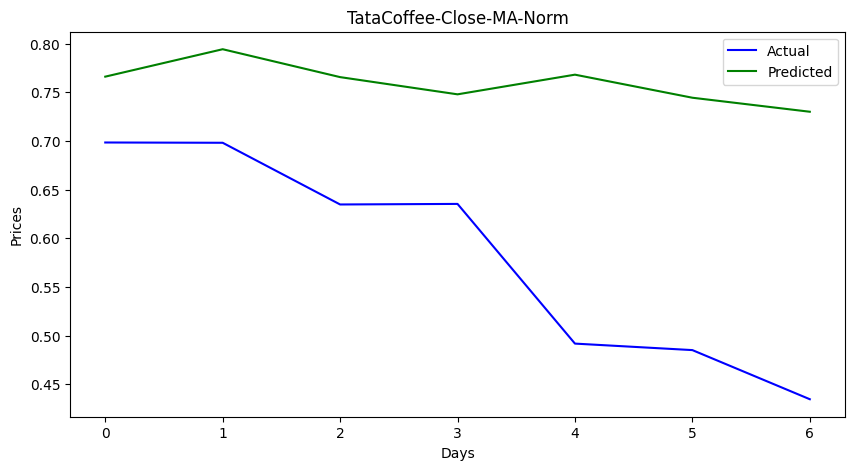

In [15]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-MA-Norm","Days","Prices")

In [16]:
len(data1)

144

In [17]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [18]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

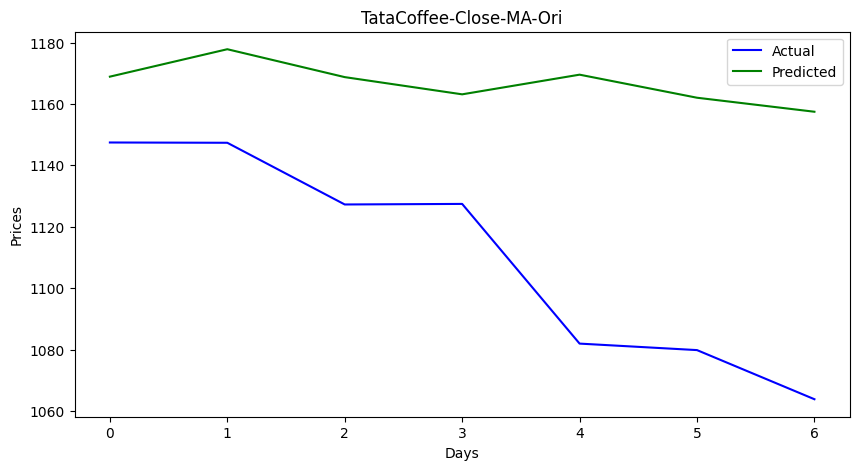

In [19]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")

In [21]:
def rmsemape(y_Test,predicted_stock_price_test_ori):
    from sklearn.metrics import mean_squared_error
    import numpy as np
    
    print("RMSE-Testset:", np.sqrt(mean_squared_error(y_Test, predicted_stock_price_test_ori)))

    from sklearn.metrics import mean_absolute_percentage_error
    print("MAPE-Testset:", mean_absolute_percentage_error(y_Test, predicted_stock_price_test_ori))

In [22]:
forecast=model_fit.predict(len(data1), len(data1))

In [23]:
forecast

array([0.72392825])

In [24]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [25]:
forecast_stock_price_test_oriF


,Closefore
0,1155.526847


In [26]:
forecast_stock_price_test_oriF.to_csv("CloseMA.csv",index=False)